In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from generator import calculate_spectral_GF, systemInit, setup_ham_rse, calculate_spectral_density
from tqdm.auto import tqdm
import sisl
from ase.visualize import view

import ipywidgets as widgets
from ipywidgets import interact, Dropdown, fixed, IntSlider
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def plot_with_index(geometry):
    x,y,z = geometry.xyz.T
    cell = geometry.cell
    A, B = cell[:-1, :-1]
    
    points = np.array([
        [0, 0],
        A,
        A + B,
        B,
        [0, 0]
    ])
    uc_x, uc_y = points.T
    fig, ax = plt.subplots(1,1,figsize=(8,6))
    
    ax.scatter(x,y, marker='o', s=100, color='grey')
    # ax.axvline(x[1])
    # print(x[1], 1+b)
    
    for i in range(0, geometry.na):
        ax.annotate(text=i, xy=(x[i], y[i]), xytext=(x[i]+0.1, y[i]+0.1))
    ax.axes.set_aspect("equal")
    ax.plot(uc_x, uc_y, color="green")
    
    xmax = np.max(geometry.cell[:, 0])
    ymax = np.max(geometry.cell[:, 1])
    ylim = (-ymax-1, ymax+1)
    xlim = (-xmax-1, xmax+1)
    ax.set(
        # ylim=ylim,
        #    xlim=xlim, 
           xlabel="x",
           ylabel="y"
           )

In [3]:
N0 = N1 = 12
ETA = 1e-3
NK1 = 500
DELTA_E = 0.1
EMAX = 0.
EMIN = -EMAX
ENERGIES = np.arange(EMAX, EMIN-DELTA_E/2, -DELTA_E)[::-1]; print(ENERGIES)

[0.]


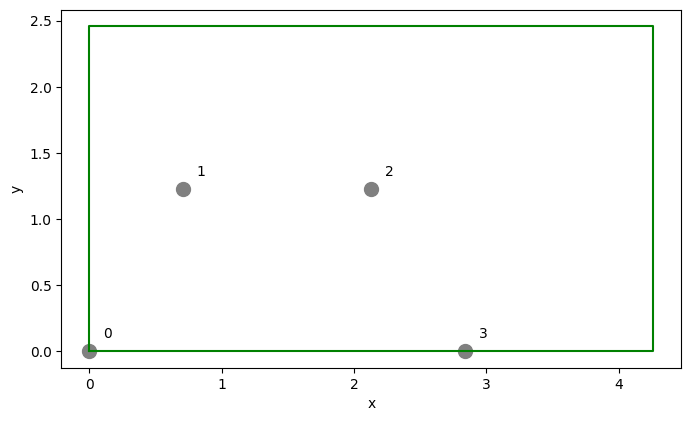

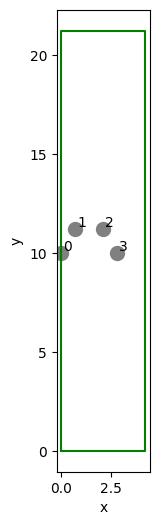

In [4]:
def make_device(bond=1.43, kind="armchair"):
    gr = sisl.geom.graphene(bond=bond, atoms="C", orthogonal=True) # returns *orthogonal* unitcell instead of primitive
    if kind == "armchair":
        return gr
    elif kind == "zigzag":
        gr = gr.rotate([180, [0,1,0]]).rotate([-90, [0,0,1]])
        xyz = gr.xyz.round(6)
        cell = gr.cell        
        atom_sort_idx = np.lexsort((xyz[:, 1], xyz[:, 0]))
        gr.set_lattice(cell[[1,0,2], :])
        gr.set_nsc([3,3,1])
        gr.sub(atom_sort_idx)
        return gr
plot_with_index(make_device(1.42, 'armchair'))
plot_with_index(sisl.geom.graphene_nanoribbon(2, 1.42))

In [5]:
a = 1.42
theta = 2*np.pi/3
phi = theta/2
b = a*np.sqrt(3)*0.5
h = a*0.5
gr = sisl.geom.graphene(bond=a)
prim_cell = gr.cell

In [6]:
Rz = lambda theta: np.array([[np.cos(theta), -np.sin(theta), 0],
                              [np.sin(theta), np.cos(theta), 0],
                              [0,0,1]])
Rx = lambda theta: Rz(theta)[np.ix_([2,0,1], [2,0,1])]
Ry = lambda theta: Rz(theta)[np.ix_([1,2,0], [1,2,0])]

In [7]:
cell_length = 3*a
horizontal = np.array([cell_length, 0, 0])

cell = np.array([Rz(-phi/2)@horizontal,
                 Rz(phi/2)@horizontal,
                 [0., 0., 20.]])

gr = sisl.geom.graphene_flake(shells=0, bond=a)
gr = gr.translate(-gr.center())
gr.set_lattice(cell)
gr = gr.rotate([phi/2, [0,0,1]], rad=True, what="xyz")
gr = gr.translate([2*b, 0, 0])
gr = gr.tile(5,0).tile(3,1)
dists = np.linalg.norm(gr.xyz[:, None, :] - gr.xyz[None, :, :], axis=-1)
site = 5
NN = np.where(np.isclose(dists[site, :], a), True, False)
gr.plot(axes="xy",atoms_style=[
    dict(atoms=NN, color="red"),
    dict(atoms=site, color="blue")
])

warn:0: SislWarning:

Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.



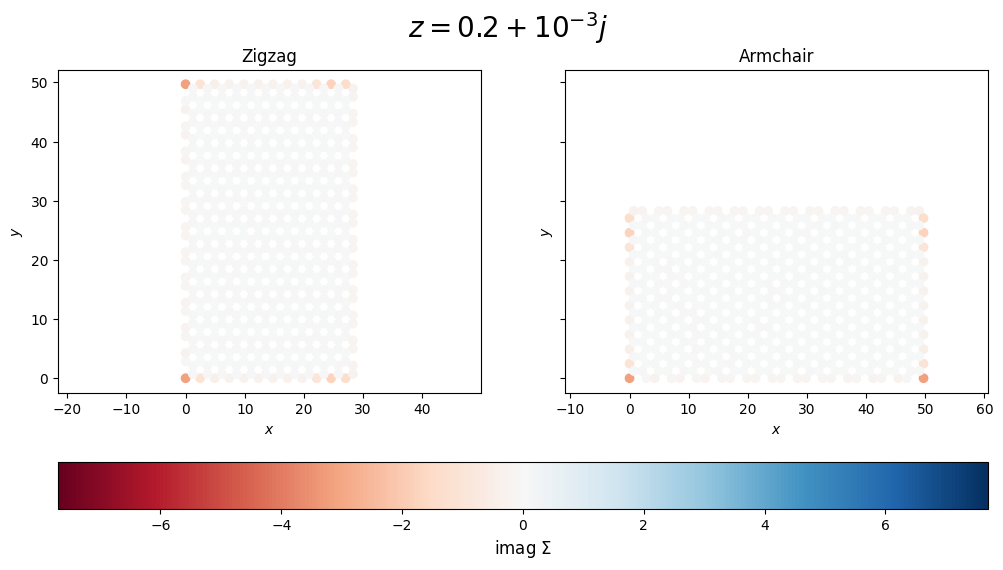

In [8]:
fig, axes = plt.subplots(1,2,figsize=(12,6), sharey=True)
for i, kind in enumerate(["zigzag", "armchair"]):
    gr = make_device(bond=a, kind=kind)
    Ham0 = sisl.Hamiltonian(gr)
    Ham0.set_nsc([3,3,1]) # needed for nanoribbon
    r = (0.1, a+1e-1)
    t = (0.0, -2.7)
    Ham0.construct([r, t])

    rse = sisl.RealSpaceSE(Ham0, 0, 1, (N0, N1, 1))
    rse.setup(eta=ETA,
            bz=sisl.MonkhorstPack(Ham0, [1, NK1, 1]))
    elec_ham, elec_idx = rse.real_space_coupling(ret_indices=True)
    
    HamNN = Ham0.tile(N0,0).tile(N1,1)
    all_atoms = np.arange(0, HamNN.na)
    inside_aotms = np.delete(all_atoms, elec_idx)
    alist = np.concatenate([elec_idx, inside_aotms])
    Ham_sub = HamNN.sub(alist)
    Ham_sub.reduce()
    E = 0.2
    RSE = rse.self_energy(E + ETA*1j)
    RSE_sub = RSE[alist,:][:,alist]

    # --- plotting ---
    part = "imag"
    use_sub = True


    if use_sub:
        x,y,z = Ham_sub.xyz.T
        rse_diag = np.diagonal(RSE_sub).copy()
    else:
        x,y,z = HamNN.xyz.T
        rse_diag = np.diagonal(RSE).copy()
    
    vmax = np.abs([np.imag(rse_diag), np.real(rse_diag)]).max()
    vmin = -vmax
        

    if part == "imag": rse_diag = np.imag(rse_diag)
    else: rse_diag = np.real(rse_diag)
    
    sc = axes[i].scatter(x, y, c=rse_diag, vmin=vmin, vmax=vmax, cmap="RdBu")
    axes[i].set(xlabel=r"$x$",
                ylabel=r"$y$",
                title=f"{kind.capitalize()}")

    axes[i].axis("equal")

fig.suptitle(rf"$z = {E:.1f} + 10^{{{np.log10(ETA):.0f}}}j$", size=20)
cbar = fig.colorbar(sc, ax=axes, location="bottom", orientation="horizontal", pad=0.15)
cbar.set_label(rf"{part} $\Sigma$", size=12)
# fig.tight_layout()
fig.canvas.draw()


# Creating armchair edge rombic structure

In [9]:
def all_armchair(bond):
    gr = sisl.geom.graphene_flake(0, bond=bond)
    gr = gr\
        .translate(-gr.center())\
            .rotate([phi/2, [0,0,1]], rad=True, what="xyz") \
                .translate([2*b, 0, 0])
                
    base = np.array([3*a, 0, 0])
    armchair_cell = np.array([Rz(-phi/2)@base,
                            Rz(phi/2)@base,
                            [0,0,20]])
    gr.set_lattice(armchair_cell)
    sort_idx = np.lexsort([gr.xyz[:, 2], gr.xyz[:, 1], gr.xyz[:, 0]])
    gr = gr.sub(sort_idx)
    return gr

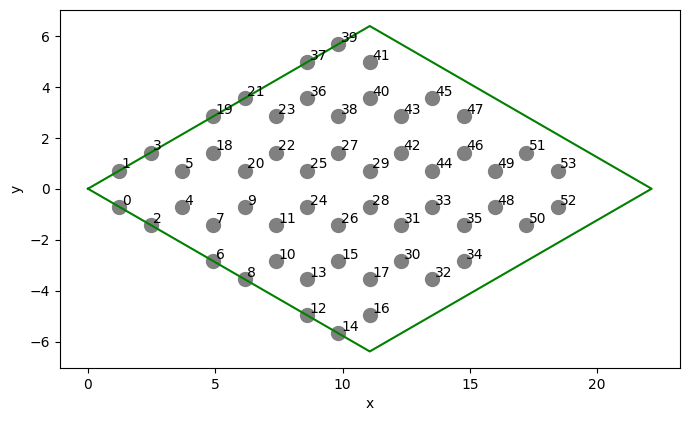

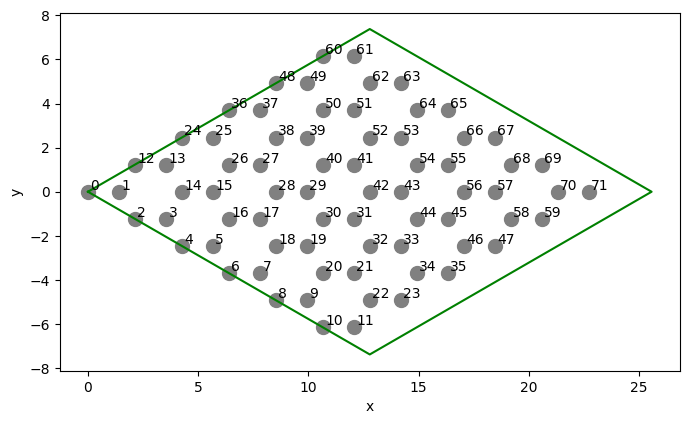

In [10]:
# gr = sisl.geom.graphene_flake(0, bond=a)
# gr = gr\
#     .translate(-gr.center())\
#         .rotate([phi/2, [0,0,1]], rad=True, what="xyz") \
#             .translate([2*b, 0, 0])
            
# base = np.array([3*a, 0, 0])
# armchair_cell = np.array([Rz(-phi/2)@base,
#                           Rz(phi/2)@base,
#                           [0,0,20]])
# gr.set_lattice(armchair_cell)
# # print(gr.xyz)
# sort_idx = np.lexsort([gr.xyz[:, 2], gr.xyz[:, 1], gr.xyz[:, 0]])
# # print(sort_idx)
# gr = gr.sub(sort_idx)

gr = all_armchair(a)
plot_with_index(gr.tile(3,0).tile(3,1))
# view(gr.to.ase())

# for armchair
gr = sisl.geom.graphene(bond=a)
plot_with_index(gr.tile(3*2,0).tile(3*2,1))


In [11]:
Ham0 = sisl.Hamiltonian(gr)
Ham0.set_nsc([3,3,1])
r = (0.1, a+1e-2)
t = (0., -2.7)
Ham0.construct([r, t])
print(Ham0.Hk(format="array"))
rse = sisl.RealSpaceSE(Ham0, 0, 1, (N0*2, N1*2, 1))
rse.setup(eta=ETA, 
          bz=sisl.MonkhorstPack(Ham0, [1, NK1, 1]))
HamNN = rse.real_space_parent()
HamNN.set_nsc([1,1,1])
Helec, elec_idx = rse.real_space_coupling(ret_indices=True)

all_idx = np.arange(0, HamNN.na)
device_idx = np.delete(all_idx, elec_idx)
all_idx = np.concatenate([elec_idx, device_idx])

z = -0 + ETA*1j
RSE = rse.self_energy(z)

RSE = RSE[all_idx, :][:, all_idx]
Ham_sub = HamNN.sub(all_idx)

# plot_with_index(Ham_sub)

# HamNN.geometry.plot(axes="xy",
#                       atoms_style=[
#                           dict(atoms=device_idx, color="grey", size=0.5),
#                           dict(atoms=elec_idx, color="red", size=0.5),
#                       ])

[[ 0.  -8.1]
 [-8.1  0. ]]


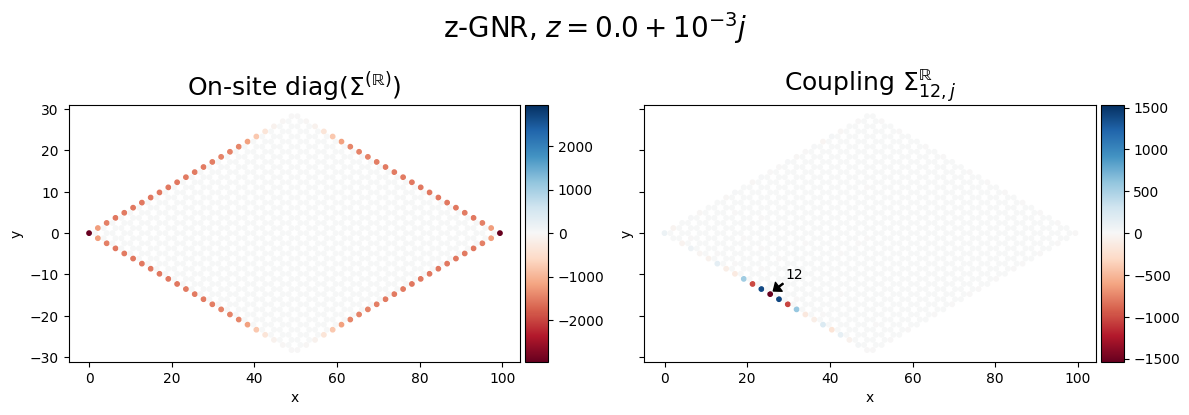

In [12]:
xyz = Ham_sub.xyz
x,y, = xyz[:, :2].T

site = (N0*2) // 2 
site_coupling = np.imag(RSE[site, :])
max_dist = np.linalg.norm(xyz[site, :] - xyz[:, :], axis=-1).max()
vmax = np.abs(site_coupling).max()
vmin = -vmax

fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True)

sc = axes[0].scatter(x,y, c=np.imag(np.diag(RSE)), s=10, vmin=-np.abs(np.diag(RSE)).max(), vmax=np.abs(np.diag(RSE)).max(), cmap="RdBu")
divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size="5%", pad=0.05)
fig.colorbar(sc, cax)
sc = axes[1].scatter(x, y, c=site_coupling, s=10, vmin=vmin, vmax=vmax, cmap="RdBu")
axes[1].annotate(text=site, xy=(x[site]+1e-2*max_dist, y[site]+1e-2*max_dist), xytext=[x[site]+5e-2*max_dist, y[site]+5e-2*max_dist],
            arrowprops=dict(color="k", headwidth=8, headlength=5, width=0.8))


divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size="5%", pad=0.05)
fig.colorbar(sc, cax)
for ax in axes:
    ax.axis("scaled")
    ax.set(xlabel="x", ylabel="y")

axes[0].set_title(r"On-site $\mathrm{diag\left(\Sigma^{(\mathbb{R})}\right)}$", size=18)
axes[1].set_title(rf"Coupling $\Sigma^{{\mathrm{{\mathbb{{R}}}}}}_{{{site}, j}}$", size=18)
    
fig.suptitle(fr"z-GNR, $z = {np.real(z):.1f} + 10^{{{np.log10(np.imag(z)):.0f}}}j$", size=20)
fig.tight_layout(rect=[0,0,1,1.3])